# Clusterização de Municípios Brasileiros — Baseline (KMeans)

**Objetivo:** estabelecer um modelo baseline de clusterização usando KMeans sobre as variáveis numéricas, servindo de referência para a comparação de modelos no notebook `03_Comparacao_Modelos`.

Seguindo a convenção do projeto, o conjunto é separado em **treino/teste antes de qualquer transformação** (log, padronização, etc.), para evitar vazamento de dados: o scaler é ajustado (`fit`) apenas no treino e depois aplicado (`transform`) no teste.

## 1. Imports

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

PASTA_REPORTS = "../reports"
PASTA_MODELS = "../models"
PASTA_DATA = "../data"
os.makedirs(PASTA_REPORTS, exist_ok=True)
os.makedirs(PASTA_MODELS, exist_ok=True)

## 2. Carregar dados e limpar

In [2]:
df = pd.read_csv(f"{PASTA_DATA}/municipios_brasil.csv")

# Removendo o único município sem dados de população/PIB (identificado na EDA)
df = df.dropna().reset_index(drop=True)
print("Linhas após remover ausentes:", len(df))

COLUNAS_NUMERICAS = [
    "populacao",
    "pib_total_mil_reais",
    "vab_agropecuaria_mil_reais",
    "vab_industria_mil_reais",
    "vab_servicos_mil_reais",
    "vab_adm_publica_mil_reais",
    "pib_per_capita_reais",
]
COLUNAS_ID = ["codigo_municipio", "municipio", "uf_sigla", "regiao"]

# Um município (Cachoeira Dourada - GO) tem VAB da indústria negativo (peculiaridade
# da série do IBGE, ver EDA); log1p exige valores >= 0, então limitamos a 0.
df[COLUNAS_NUMERICAS] = df[COLUNAS_NUMERICAS].clip(lower=0)

df.head()

Linhas após remover ausentes: 5570


,codigo_municipio,municipio,uf_sigla,uf_nome,regiao,mesorregiao,microrregiao,populacao,pib_total_mil_reais,vab_adm_publica_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,pib_per_capita_reais
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,22516.0,734467.0,173122.0,311469.0,27845.0,172435.0,32619.781489
1,1100023,Ariquemes,RO,Rondônia,Norte,Leste Rondoniense,Ariquemes,111148.0,3211294.0,782306.0,293001.0,407675.0,1307977.0,28892.053838
2,1100031,Cabixi,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,5067.0,238414.0,46579.0,136659.0,8117.0,35866.0,47052.299191
3,1100049,Cacoal,RO,Rondônia,Norte,Leste Rondoniense,Cacoal,86416.0,2792506.0,629109.0,341315.0,236801.0,1200654.0,32314.687095
4,1100056,Cerejeiras,RO,Rondônia,Norte,Leste Rondoniense,Colorado do Oeste,16088.0,743062.0,123365.0,151690.0,27433.0,308668.0,46187.344605


## 3. Separar treino/teste (antes de qualquer transformação)

A separação é feita agora, sobre os dados **brutos**, para que o `log1p` + `StandardScaler` sejam ajustados apenas no treino — evitando vazamento de informação do teste para o pré-processamento.

In [3]:
df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df["regiao"]
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Treino:", df_train.shape, "| Teste:", df_test.shape)

# Persistindo a divisão para reutilizar nos notebooks seguintes (03 e 04)
df_train.to_csv(f"{PASTA_DATA}/municipios_train.csv", index=False)
df_test.to_csv(f"{PASTA_DATA}/municipios_test.csv", index=False)

Treino: (4456, 14) | Teste: (1114, 14)


## 4. Pré-processamento (log1p + padronização)

In [4]:
X_train_log = np.log1p(df_train[COLUNAS_NUMERICAS])
X_test_log = np.log1p(df_test[COLUNAS_NUMERICAS])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_log)
X_test = scaler.transform(X_test_log)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (4456, 7) | X_test: (1114, 7)


## 5. Método do cotovelo (escolher k)

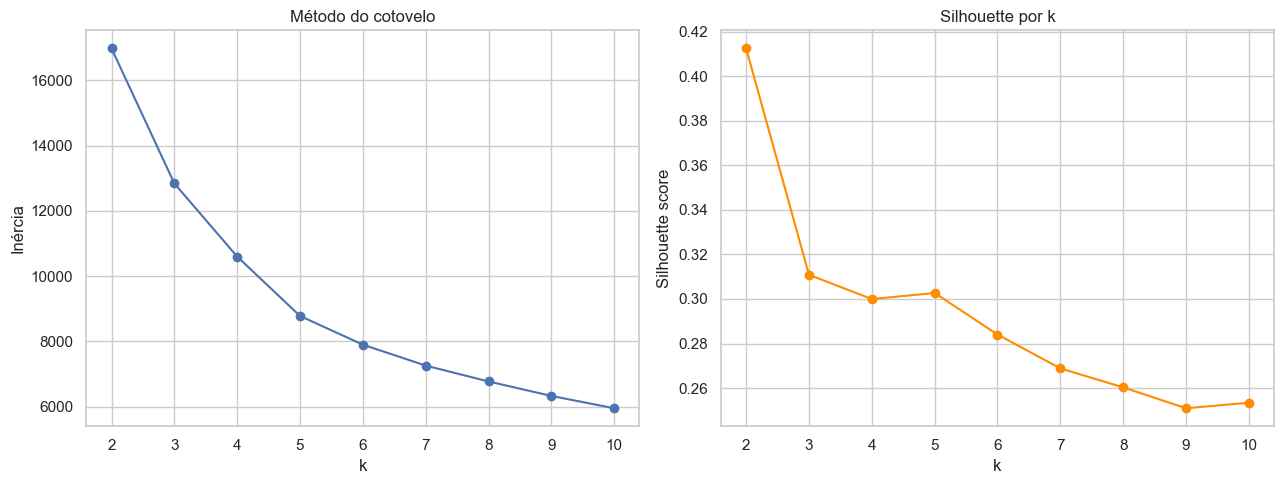

In [5]:
ks = range(2, 11)
inercias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_train)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(ks), inercias, "o-")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")
axes[0].set_title("Método do cotovelo")

axes[1].plot(list(ks), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette por k")

plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/baseline_cotovelo_silhouette.png", dpi=120)
plt.show()

In [6]:
K_ESCOLHIDO = list(ks)[int(np.argmax(silhouettes))]
print(f"k escolhido (maior silhouette no treino): {K_ESCOLHIDO}")
print(dict(zip(ks, np.round(silhouettes, 3))))

k escolhido (maior silhouette no treino): 2
{2: 0.412, 3: 0.311, 4: 0.3, 5: 0.303, 6: 0.284, 7: 0.269, 8: 0.26, 9: 0.251, 10: 0.253}


## 6. Treinar o modelo baseline final (KMeans)

In [7]:
kmeans_baseline = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
kmeans_baseline.fit(X_train)

labels_train = kmeans_baseline.labels_
labels_test = kmeans_baseline.predict(X_test)

sil_train = silhouette_score(X_train, labels_train)
sil_test = silhouette_score(X_test, labels_test)

print(f"Silhouette treino: {sil_train:.3f}")
print(f"Silhouette teste:  {sil_test:.3f}")
print("\nTamanho dos clusters (treino):")
print(pd.Series(labels_train).value_counts().sort_index())

Silhouette treino: 0.412
Silhouette teste:  0.405

Tamanho dos clusters (treino):
0    1455
1    3001
Name: count, dtype: int64


## 7. Visualizar clusters com PCA (2D)

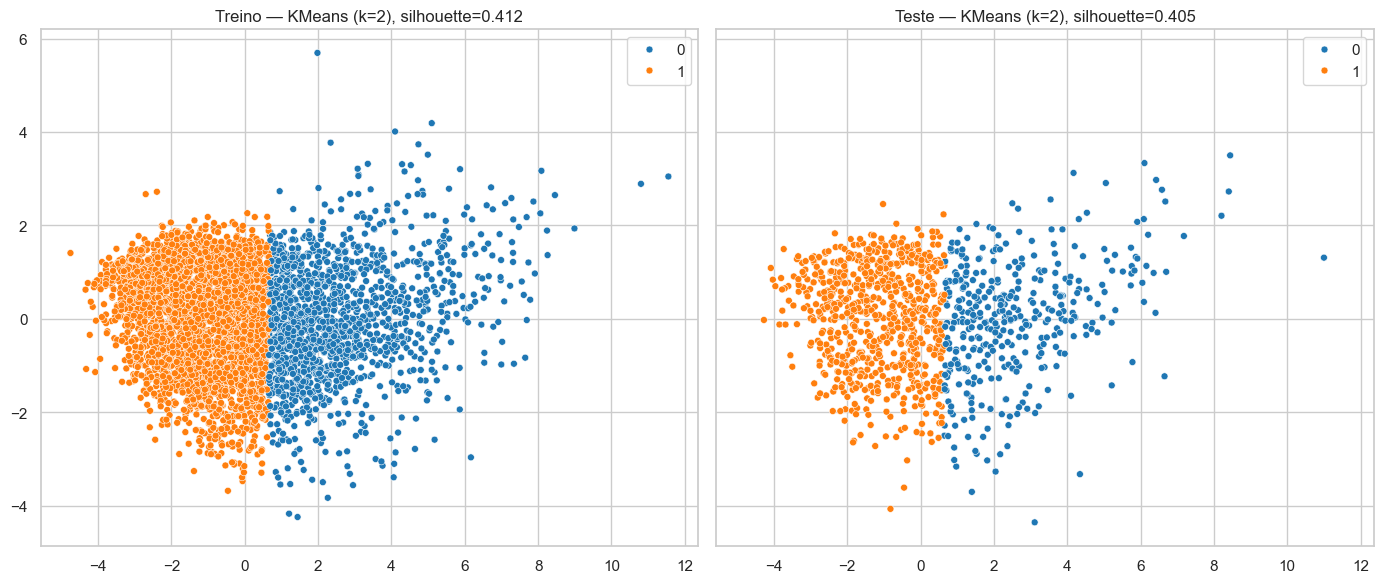

Variância explicada pelas 2 componentes: 89.1%


In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=labels_train, palette="tab10", ax=axes[0], s=25
)
axes[0].set_title(f"Treino — KMeans (k={K_ESCOLHIDO}), silhouette={sil_train:.3f}")

sns.scatterplot(
    x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=labels_test, palette="tab10", ax=axes[1], s=25
)
axes[1].set_title(f"Teste — KMeans (k={K_ESCOLHIDO}), silhouette={sil_test:.3f}")

plt.tight_layout()
plt.savefig(f"{PASTA_REPORTS}/baseline_pca_clusters.png", dpi=120)
plt.show()

print(f"Variância explicada pelas 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

## 8. Perfil dos clusters (treino)

In [9]:
df_perfil = df_train.copy()
df_perfil["cluster"] = labels_train
df_perfil.groupby("cluster")[COLUNAS_NUMERICAS].median()

,populacao,pib_total_mil_reais,vab_agropecuaria_mil_reais,vab_industria_mil_reais,vab_servicos_mil_reais,vab_adm_publica_mil_reais,pib_per_capita_reais
cluster,,,,,,,
0,35705.0,1177795.0,107405.0,221938.0,387659.0,188395.0,37158.014608
1,7124.0,148983.0,29924.0,7439.0,35304.0,39865.0,17226.155359


## 9. Salvar modelo baseline

In [10]:
joblib.dump(scaler, f"{PASTA_MODELS}/baseline_scaler.joblib")
joblib.dump(kmeans_baseline, f"{PASTA_MODELS}/baseline_kmeans.joblib")
print("Modelo e scaler salvos em", PASTA_MODELS)

Modelo e scaler salvos em ../models


## 10. Conclusão do baseline

O KMeans com `k` escolhido pelo maior silhouette no treino apresenta desempenho consistente entre treino e teste (silhouette semelhante nos dois conjuntos), servindo como referência.

**Próximos passos (`03_Comparacao_Modelos`):** comparar este baseline com AgglomerativeClustering, DBSCAN e variantes (HDBSCAN, OPTICS), além de KModes e KPrototypes, que aproveitam as variáveis categóricas (`regiao`, `uf_sigla`) ignoradas aqui.